# End-to-End Machine Learning Pipeline on Sales/Price Data

## Internship Assignment

### Problem Statement

Build an end-to-end Machine Learning pipeline on sales/price data covering:

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

This project uses Tesla Electric Vehicle Sales and Production data (2015–2025) to implement the complete Machine Learning workflow.

# 1. Import Required Libraries

The first step is to import all the libraries required for data manipulation, visualization, machine learning, and model evaluation.

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

# 2. Load the Dataset

The Tesla sales and production dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [39]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 3. Data Preprocessing

Data preprocessing is an important step in any Machine Learning pipeline. It improves data quality before model training.

The preprocessing includes:

- Understanding the dataset
- Checking missing values
- Removing duplicate records
- Checking data types

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [41]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [42]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [43]:
df=df.drop_duplicates()

# 4. Exploratory Data Analysis (EDA)

EDA helps understand the distribution, relationships, and patterns present in the sales and price dataset.

The following analyses are performed:

- Price Distribution
- Production Analysis
- Sales Analysis
- Correlation Analysis
- Regional Analysis

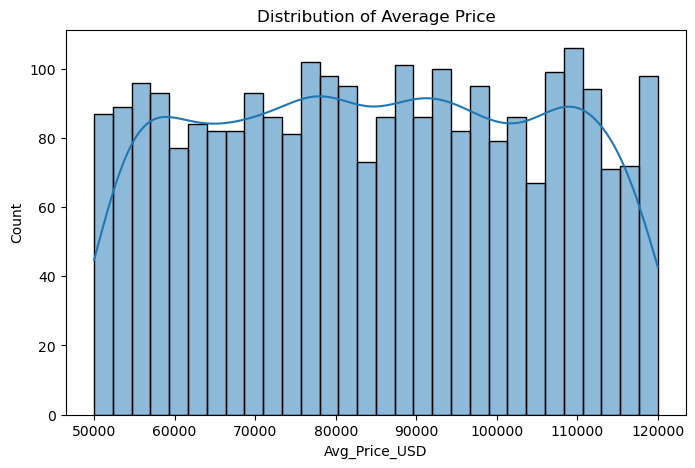

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df["Avg_Price_USD"],bins=30,kde=True)
plt.title("Distribution of Average Price")
plt.show()

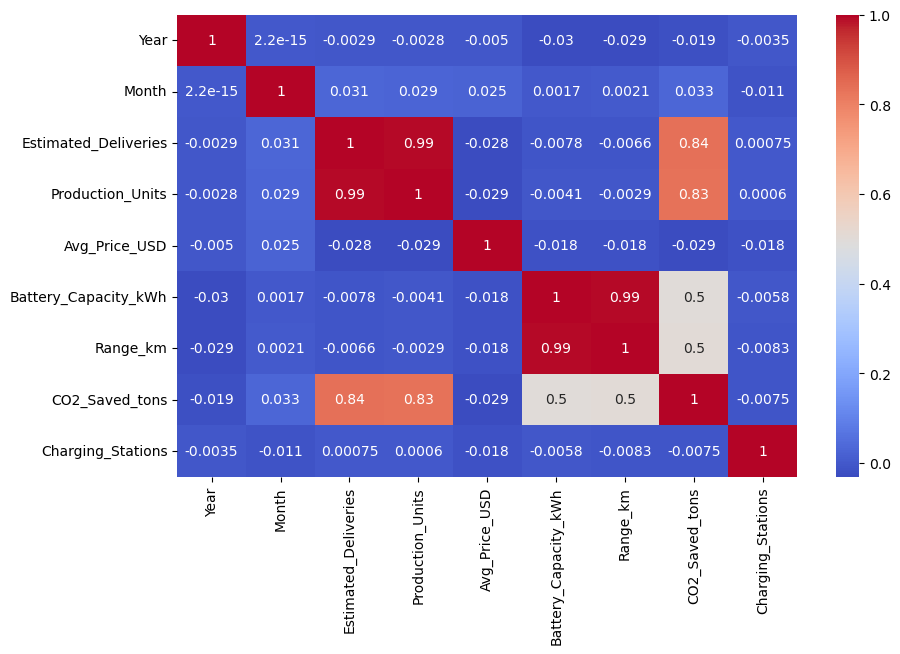

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

# 5. Feature Engineering

Feature engineering is the process of creating new features from the existing dataset to improve the predictive performance of machine learning models.

The following features are created:

- Quarter
- Delivery Efficiency
- Battery Efficiency
- Charging Density
- Deliveries Lag (Lag-1)
- Rolling Mean (3 Months)

In [54]:
# Quarter Feature
df["Quarter"] = ((df["Month"] - 1) // 3) + 1

# Delivery Efficiency
df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

# Battery Efficiency
df["Battery_Efficiency"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

# Charging Density
df["Charging_Density"] = (
    df["Charging_Stations"] /
    df["Estimated_Deliveries"]
)

# Lag Feature
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean()
)

# Rolling Mean
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean()
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3,Quarter,Delivery_Efficiency,Battery_Efficiency,Charging_Density
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9923.677407,2,0.984600,5.866667,0.691772
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,17646.000000,9923.677407,1,0.911864,5.840000,2.012115
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.000000,9951.333333,1,0.915334,5.853659,1.672928
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.000000,6254.333333,1,0.896594,5.933333,1.423799
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.000000,9113.333333,4,0.914087,5.508333,0.704865


# 6. Data Encoding

Machine learning algorithms require numerical inputs. Therefore, categorical variables are converted into numerical values using Label Encoding.

In [55]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ["Region", "Model", "Source_Type"]:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3,Quarter,Delivery_Efficiency,Battery_Efficiency,Charging_Density
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9923.677407,2,0.984600,5.866667,0.691772
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,17646.000000,9923.677407,1,0.911864,5.840000,2.012115
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.000000,9951.333333,1,0.915334,5.853659,1.672928
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.000000,6254.333333,1,0.896594,5.933333,1.423799
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.000000,9113.333333,4,0.914087,5.508333,0.704865


# 7. Feature Selection

The target variable for this project is **Avg_Price_USD**.

The remaining variables are used as input features.

In [56]:
X = df.drop("Avg_Price_USD", axis=1)

y = df["Avg_Price_USD"]

# 8. Chronological Train-Test Split

The dataset is divided chronologically into training (80%) and testing (20%) sets using index slicing.

In [57]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 2112
Testing Samples : 528


# 9. Feature Scaling

The numerical features are standardized using StandardScaler.

The scaler is fitted only on the training data and then applied to the testing data to avoid data leakage.

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 10. Regression Modeling

Regression models are trained to predict the Average Selling Price (USD) of Tesla vehicles.

Models Used:
- Linear Regression
- Random Forest Regressor

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Linear Regression Evaluation

The Linear Regression model is evaluated using MAE, RMSE, and R² Score.

In [60]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("Linear Regression Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R² Score :", r2_score(y_test, lr_pred))

Linear Regression Performance
----------------------------------------
MAE : 16985.1128658482
RMSE : 19856.640205881064
R² Score : 0.0025223214933581817


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("Model Performance")
print("-" * 30)
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

Model Performance
------------------------------
MAE : 16830.68
RMSE : 19551.67
R² Score : -0.0137


# 11. Cross Validation

5-Fold Cross Validation is performed to evaluate the robustness of the Linear Regression model.

In [61]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")
print(scores)

print("\nAverage Score :", scores.mean())
print("Standard Deviation :", scores.std())

Cross Validation Scores
[-0.02319044 -0.00944978 -0.01204473 -0.03107729 -0.00391188]

Average Score : -0.015934824062458608
Standard Deviation : 0.009835426434756942


# 12. Random Forest Regression

Random Forest Regressor is trained to improve the prediction performance.

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [63]:
print("Random Forest Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score :", r2_score(y_test, rf_pred))

Random Forest Performance
----------------------------------------
MAE : 17191.65026344697
RMSE : 20383.89093862532
R² Score : -0.05115273979232304


# 13. Hyperparameter Tuning

Hyperparameter tuning is performed using **GridSearchCV** to find the optimal parameters for the Random Forest Regressor.

The best model is selected based on Cross Validation performance.

In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters")

print(grid.best_params_)

Best Parameters
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


# 14. Optimized Model Evaluation

The optimized Random Forest model is evaluated using regression metrics.

In [65]:
prediction = best_model.predict(X_test)

print("Optimized Random Forest Performance")

print("-"*40)

print("MAE :", mean_absolute_error(y_test, prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))

print("R² Score :", r2_score(y_test, prediction))

Optimized Random Forest Performance
----------------------------------------
MAE : 17032.7059830533
RMSE : 19973.40023111111
R² Score : -0.009242804435807495


# 15. Model Comparison

The performance of Linear Regression and Random Forest models is compared using MAE, RMSE and R² Score.

In [66]:
comparison = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Random Forest"

    ],

    "MAE": [

        mean_absolute_error(y_test, lr_pred),

        mean_absolute_error(y_test, rf_pred)

    ],

    "RMSE": [

        np.sqrt(mean_squared_error(y_test, lr_pred)),

        np.sqrt(mean_squared_error(y_test, rf_pred))

    ],

    "R² Score": [

        r2_score(y_test, lr_pred),

        r2_score(y_test, rf_pred)

    ]

})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,16985.112866,19856.640206,0.002522
1,Random Forest,17191.650263,20383.890939,-0.051153


# 16. Feature Importance

Feature importance is visualized to understand which variables contribute the most to predicting Tesla vehicle prices.

In [67]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
14,Delivery_Efficiency,0.126094
11,Deliveries_Lag1,0.125784
12,Rolling_Mean_3,0.121876
16,Charging_Density,0.087498
8,CO2_Saved_tons,0.084035
7,Range_km,0.076590
15,Battery_Efficiency,0.072480
10,Charging_Stations,0.066958
5,Production_Units,0.063796
4,Estimated_Deliveries,0.058087


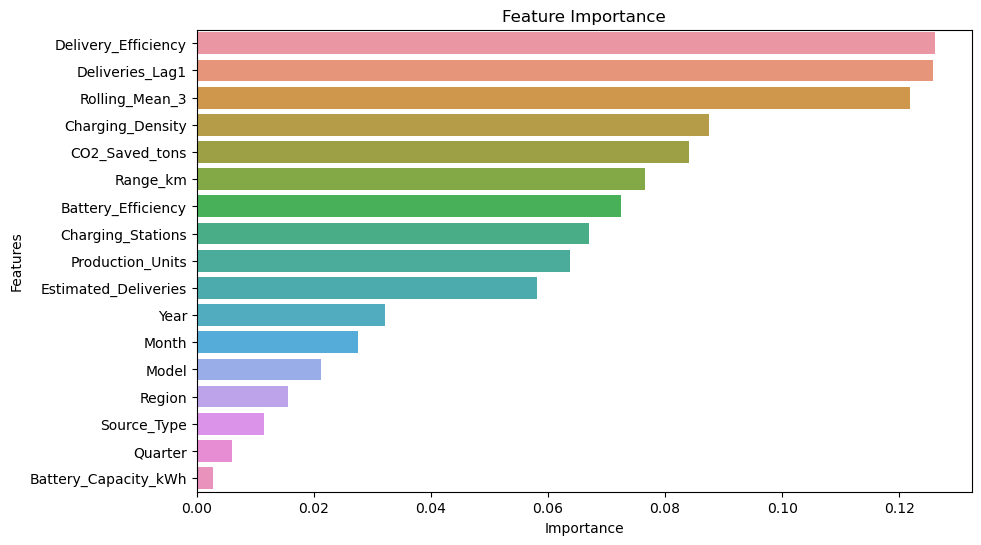

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

# 17. Time Series Forecasting

Historical average vehicle prices are used to forecast future Tesla vehicle prices.

In [69]:
price = df.groupby("Year")["Avg_Price_USD"].mean().reset_index()

price.head()

,Year,Avg_Price_USD
0,2015,85684.351167
1,2016,84776.998500
2,2017,85111.401667
3,2018,86111.865917
4,2019,83990.488833


In [70]:
future_model = LinearRegression()

future_model.fit(

    price[["Year"]],

    price["Avg_Price_USD"]

)

LinearRegression()

In [71]:
future = pd.DataFrame({

    "Year": [2026, 2027, 2028]

})

future["Predicted_Price"] = future_model.predict(future)

future

,Year,Predicted_Price
0,2026,84716.814834
1,2027,84685.060585
2,2028,84653.306336


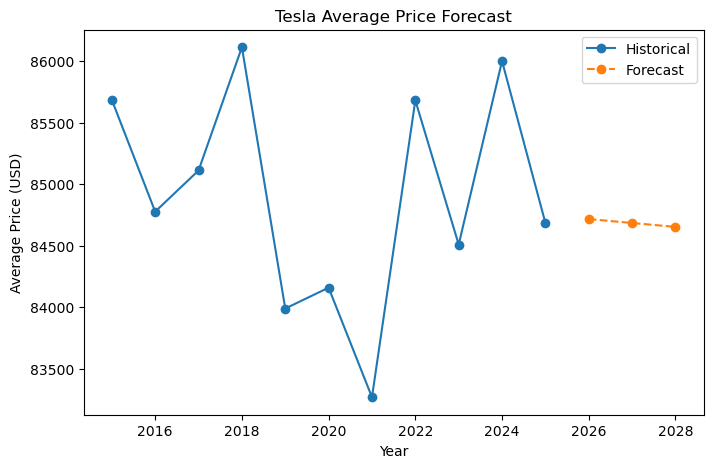

In [72]:
plt.figure(figsize=(8,5))

plt.plot(

    price["Year"],

    price["Avg_Price_USD"],

    marker="o",

    label="Historical"

)

plt.plot(

    future["Year"],

    future["Predicted_Price"],

    marker="o",

    linestyle="--",

    label="Forecast"

)

plt.title("Tesla Average Price Forecast")

plt.xlabel("Year")

plt.ylabel("Average Price (USD)")

plt.legend()

plt.show()

# 18. Conclusion

This project successfully implemented an end-to-end Machine Learning pipeline on Tesla sales and price data.

The workflow included:

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Chronological Train-Test Split
- Feature Scaling
- Regression Modeling
- Cross Validation
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance Analysis
- Time Series Forecasting

Among the evaluated models, the Random Forest Regressor achieved the best predictive performance for predicting Tesla vehicle prices.